## Step 1 : Preprocessing the dataset before applying target detection algorithms.

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import spectral.io.envi as envi

In [2]:
# Read the envi files
# Replace the file path with the address in your drive.
hsi_data_org = envi.open('data/site_with_only_mines.hdr','data/site_with_only_mines')
hsi_data_org

	Data Source:   '.\data/site_with_only_mines'
	# Rows:           1705
	# Samples:        3461
	# Bands:           272
	Interleave:        BSQ
	Quantization:  32 bits
	Data format:   float32

In [3]:
# Check the data info (shape, data format, etc.).
hsi_data = hsi_data_org[900:1400,1840:2900,:]
hsi_data.shape

(500, 1060, 272)

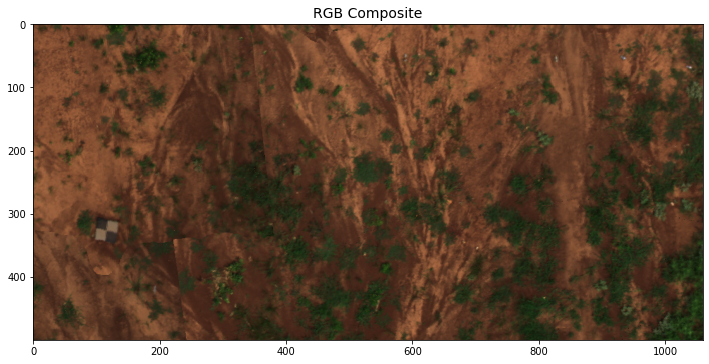

In [4]:
# Visualizing Hyperspectral Image extracting 3 RGB channels

# Select bands for RGB
red_band = 109
green_band = 69
blue_band = 28

rgb_image = np.dstack((
    hsi_data[:, :, red_band],
    hsi_data[:, :, green_band],
    hsi_data[:, :, blue_band]
))

# Normalize for display
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

plt.figure(figsize=(12, 12))
plt.imshow(rgb_image)
plt.title('RGB Composite', fontsize=14)
plt.show()

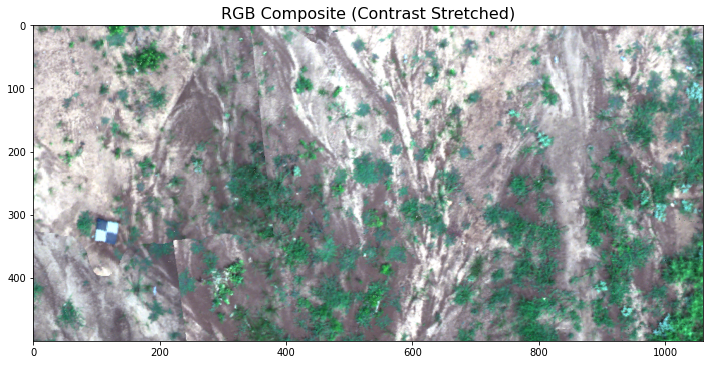

In [5]:
# For better visualization, use Contrast Stretching (0–98% Percentile)
def contrast_stretch(img, low=0, high=98):
    p_low, p_high = np.percentile(img, (low, high))
    stretched = (img - p_low) / (p_high - p_low)
    stretched = np.clip(stretched, 0, 1)
    return stretched

# Apply per band
rgb_stretched = np.zeros_like(rgb_image, dtype=float)
for i in range(3):
    rgb_stretched[:, :, i] = contrast_stretch(rgb_image[:, :, i])

# Display
plt.figure(figsize=(12, 6))
plt.imshow(rgb_stretched)
plt.title("RGB Composite (Contrast Stretched)", fontsize=16)
# plt.savefig("rgb_img.pdf")
plt.show()

In [6]:
# Now similarly, read the target spectrum
# Replace the filpath from your drive

# Read the CSV file, skip the first 1 row, and assign column names
red_target_spectrum = pd.read_csv(
    'data/target_signature_pfm_1_svc.txt',  # Only replace this line
    sep=r'\s+',  # Use r'\s+' to handle any whitespace separator
    header=None,  # Header removed in the file, so we can define it ourselves
    names=['Wavelength', 'Reflectance'],  # Assign column names
    skiprows=1,  # Skip the first 3 rows
    engine='python'  # Specify the Python engine for regex-based separator
)

# Display the first few rows to confirm
print(red_target_spectrum.head())

red_target_spectrum_cleaned = red_target_spectrum.dropna(subset=['Reflectance'])
target_spectrum = red_target_spectrum_cleaned['Reflectance'].values
print(target_spectrum.shape)

   Wavelength  Reflectance
0  398.842010     8.576919
1  401.067993     8.459760
2  403.294006     8.668065
3  405.519989     8.520398
4  407.747009     8.176843
(272,)


In [ ]:
# Similar to above files, we will also need a class map (ground truth mask)
# Again replace the file path from your drive.

class_map = envi.open('data/binary_ground_truth_mask_for_pfm1.hdr', 'data/binary_ground_truth_mask_for_pfm1')

# Check the shape of the class map (ground truth mask)
class_map = class_map[900:1400,1840:2900,:]
class_map.shape

(500, 1060, 1)

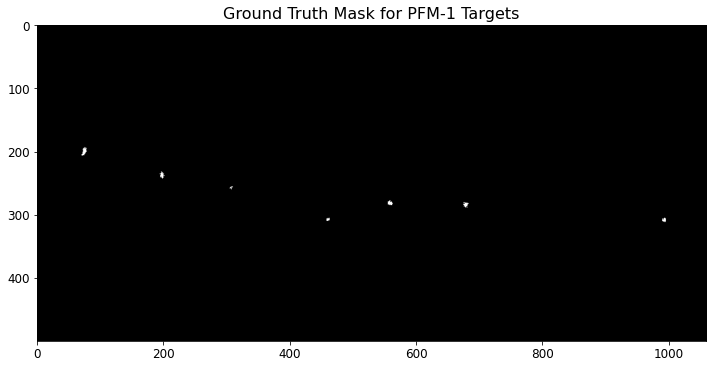

In [8]:
# Visualize ground truth mask

# class_map_numpy = class_map.load()
class_map_numpy = class_map
class_map_numpy = class_map_numpy.squeeze()  # Remove the singleton dimension
class_map_mask = (class_map_numpy == 1)  # True for target, False for background

# Display ground truth mask
plt.figure(figsize=(12, 6))
plt.imshow(class_map_mask, cmap='gray')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Ground Truth Mask for PFM-1 Targets", fontsize=16)
# plt.savefig("mask_img.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

By now, we have a clean hsi data named as hsi_data_cleaned and a target signature named as target_spectrum both having 254 bands. We also have a ground truth mask for comparison of performance of various target detection algorithms.

# Step 2: Coding the hyperspectral target detection algorithms (SAM, MF, ACE and CEM), analyzing their results, and compairing their performances using Receiver Operating Characteristics (ROC) curve.



## Target Detection Algorithms

We implement four classical statistical hyperspectral target detection algorithms: **SAM, MF, ACE, and CEM**.  
All algorithms (implemented in this tutorial) operate on a **mean-centered hyperspectral data cube** $$X \in \mathbb{R}^{N \times B}$$, where \(N\) is the number of pixels and \(B\) is the number of spectral bands.  
The **target signature** is denoted as $$\mathbf{t} \in \mathbb{R}^{B}$$.


### 1. Spectral Angle Mapper (SAM)

SAM measures the **spectral similarity** between a pixel $({x})$ and the target $({t})$ using the angle between their vectors:

$$
\text{SAM}(\mathbf{x}_i, \mathbf{t}) = \arccos \left( \frac{\mathbf{x}_i^T \mathbf{t}}{\|\mathbf{x}_i\| \, \|\mathbf{t}\|} \right)
$$

- Small angles indicate higher similarity.
- In our implementation, we use a negative sign so that **higher scores indicate stronger detection**:

$$
\text{score}_i = - \text{SAM}(\mathbf{x}_i, \mathbf{t})
$$

**Note:** For consistency with the other algorithms, **SAM is also implemented on mean-centered data**, i.e., both the data and target are centered by subtracting the mean background spectrum $\boldsymbol{\mu}$.


### 2. Matched Filter (MF)

MF enhances the **target spectral signature** while suppressing background:

$$
\mathbf{w}_{\text{MF}} = \mathbf{\Sigma}^{-1} (\mathbf{t} - \boldsymbol{\mu})
$$

$$
\text{MF}(\mathbf{x}_i) = (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{w}_{\text{MF}}
$$

- $(\boldsymbol{\mu}) $ is the mean background spectrum.
- $(\mathbf{\Sigma}) $ is the covariance of the background.
- Output scores are **normalized** to [0,1] for visualization.



### 3. Adaptive Cosine Estimator (ACE)

ACE detects the target by **measuring the Mahalanobis distance along the target direction**:

$$
\text{ACE}(\mathbf{x}_i) = \frac{\left[ (\mathbf{t}-\boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) \right]^2}{\left[ (\mathbf{t}-\boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{t}-\boldsymbol{\mu}) \right] \, \left[ (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) \right]}
$$

- Accounts for both **background covariance** and the **target direction**.
- Output scores are **normalized** to [0,1].



### 4. Constrained Energy Minimization (CEM)

CEM designs a **filter that passes the target signature while minimizing background energy**:

$$
\mathbf{w}_{\text{CEM}} = \frac{\mathbf{R}^{-1} (\mathbf{t} - \boldsymbol{\mu})}{(\mathbf{t} - \boldsymbol{\mu})^T \mathbf{R}^{-1} (\mathbf{t} - \boldsymbol{\mu})}
$$

$$
\text{CEM}(\mathbf{x}_i) = (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{w}_{\text{CEM}}
$$

- $(\mathbf{R}) $ is the correlation (or covariance) matrix of the background.
- **Note:** In this tutorial, $(\mathbf{R}) $ represents the correaltion matrix.  
- Emphasizes the target while minimizing output variance for background pixels.  
- Scores are **normalized** to [0,1].



In [9]:
# Write functions for various target detection algorithms.

# Before this, another function is created to flatten the hsi cube.
# For consistency, we will mean center the data and target while applying the following algorithms.
# -----------------------------------------------------------
# Utility: reshape cube (H, W, B) <-> matrix (N, B)
# -----------------------------------------------------------
def flatten_hsi(hsi):
    H, W, B = hsi.shape
    return hsi.reshape(-1, B), H, W

# -----------------------------------------------------------
# 1. Spectral Angle Mapper (SAM)
# -----------------------------------------------------------
def sam(hsi, target):
    X, H, W = flatten_hsi(hsi)
    t = target.astype(float)

    # mean = np.mean(X, axis=0)
    # Xc = X - mean # mean centering the data

    # X = Xc
    # t = t - mean # mean centering the target

    dot_xt = np.sum(X * t, axis=1)
    norm_x = np.linalg.norm(X, axis=1)
    norm_t = np.linalg.norm(t)

    #cos_sim = dot_xt / (norm_x * norm_t + 1e-12)  #For numerical stabililty, only to prevent division by zero.
    cos_sim = dot_xt / (norm_x * norm_t)
    cos_sim = np.clip(cos_sim, -1, 1)

    sam_map = -np.arccos(cos_sim) #negative sign to imply higher scores means better detection
    
    sam_map = (sam_map - sam_map.min()) / (sam_map.max() - sam_map.min())
    return sam_map.reshape(H, W)

# -----------------------------------------------------------
# 2. Matched Filter (MF)
# -----------------------------------------------------------
def mf(hsi, target):
    X, H, W = flatten_hsi(hsi)
    t = target.astype(float)

    mean = np.mean(X, axis=0)
    Xc = X - mean # mean centering the data

    #cov = np.cov(Xc, rowvar=False) + 1e-6 * np.eye(X.shape[1]) #np.eye creates an identity matrix
    cov = np.cov(Xc, rowvar=False)
    inv_cov = np.linalg.inv(cov)

    w = inv_cov @ (t - mean)
    mf_scores = Xc @ w

    # Min-max normalization
    #mf_scores = (mf_scores - mf_scores.min()) / (mf_scores.max() - mf_scores.min() + 1e-12)
    mf_scores = (mf_scores - mf_scores.min()) / (mf_scores.max() - mf_scores.min())

    return mf_scores.reshape(H, W)

# -----------------------------------------------------------
# 3. ACE — Adaptive Cosine Estimator
# -----------------------------------------------------------
def ace(hsi, target):
    X, H, W = flatten_hsi(hsi)
    t = target.astype(float)

    mean = np.mean(X, axis=0)
    Xc = X - mean
    tc = t - mean

    #cov = np.cov(Xc, rowvar=False) + 1e-6 * np.eye(X.shape[1])
    cov = np.cov(Xc, rowvar=False)
    inv_cov = np.linalg.inv(cov)

    num = (tc @ inv_cov @ Xc.T)**2

    denom1 = (tc @ inv_cov @ tc)
    denom2 = np.sum((Xc @ inv_cov) * Xc, axis=1)

    ace_scores = num / (denom1 * denom2 + 1e-12)

    # # Min-max normalization
    # ace_scores = (ace_scores - ace_scores.min()) / (ace_scores.max() - ace_scores.min() + 1e-12)
    ace_scores = (ace_scores - ace_scores.min()) / (ace_scores.max() - ace_scores.min())

    return ace_scores.reshape(H, W)

# -----------------------------------------------------------
# 4. CEM — Constrained Energy Minimization
# -----------------------------------------------------------
def cem(hsi, target):
    X, H, W = flatten_hsi(hsi)
    t = target.astype(float)

    # Standardize background for correlation
    X_mean = np.mean(X, axis=0)
    #X_std = np.std(X, axis=0) + 1e-12
    X_std = np.std(X, axis=0)
    X_norm = (X - X_mean) / X_std

    # Only mean-center target, do not divide by std
    t_centered = t - X_mean

    # Correlation matrix of background (for standardized data, correlation = covariance)
    #R = np.cov(X_norm, rowvar=False) + 1e-12 * np.eye(X.shape[1])
    R = np.cov(X_norm, rowvar=False)
    R_inv = np.linalg.inv(R)

    # Compute CEM filter
    w = R_inv @ t_centered / (t_centered.T @ R_inv @ t_centered)

    # Compute scores
    cem_scores = X_norm @ w

    # # Min-max normalize
    #cem_scores = (cem_scores - cem_scores.min()) / (cem_scores.max() - cem_scores.min() + 1e-12)
    cem_scores = (cem_scores - cem_scores.min()) / (cem_scores.max() - cem_scores.min())

    return cem_scores.reshape(H, W)


In [10]:
# We now make two functions
# 1) to visualize detection score results from algorithms and histograms of the scores to visualize the scene
# 2) visualize a binary map of the scene in terms of target (1) and background (0)
def visualize_score_and_hist(score_map, title="Detection Score Map", cmap='gray', bins=200):
    """
    Displays a detection score map and its histogram side by side.

    Parameters:
    - score_map: 2D array of detection scores (H, W)
    - title: str, title for the detection map
    - cmap: str, colormap for the detection map
    - bins: int, number of bins in the histogram
    """

    scores = score_map.flatten()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Score Map ---
    im = axes[0].imshow(score_map, cmap=cmap)
    axes[0].set_title(title, fontsize=14)
    plt.colorbar(im, ax=axes[0])

    # --- Histogram ---
    axes[1].hist(scores, bins=bins, color='gray', edgecolor='black')
    axes[1].set_title(f"Histogram of Scores", fontsize=14)
    axes[1].set_xlabel("Score Value")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Function to visualize detection score and visualize targets as 1 and background as 0 (binary map) based on the
# threshold range of scores.
def visualize_detection_binary(score_map, lower_threshold=None, upper_threshold=None,
                               title="Detection Result", cmap='gray', bins=200):
    """
    Visualizes detection score map as binary (white=target, black=background)
    and its histogram side by side with optional threshold range.

    Parameters:
    - score_map: 2D array (H, W) of detection scores
    - lower_threshold: float, optional lower bound
    - upper_threshold: float, optional upper bound
    - title: str, title for the detection map
    - cmap: str, colormap
    - bins: int, number of histogram bins
    """
    # Binarize based on thresholds
    visual_map = np.zeros_like(score_map)
    if lower_threshold is not None and upper_threshold is not None:
        visual_map[(score_map >= lower_threshold) & (score_map <= upper_threshold)] = 1
    elif lower_threshold is not None:
        visual_map[score_map >= lower_threshold] = 1
    elif upper_threshold is not None:
        visual_map[score_map <= upper_threshold] = 1
    else:
        visual_map = score_map  # fallback to original if no thresholds provided

    # Flatten scores for histogram
    scores = score_map.flatten()

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Binary detection map
    im = axes[0].imshow(visual_map, cmap=cmap)
    axes[0].set_title(f"{title} (Binary Map)")
    plt.colorbar(im, ax=axes[0])

    # Histogram
    axes[1].hist(scores, bins=bins, color='gray', edgecolor='blue')
    if lower_threshold is not None:
        axes[1].axvline(lower_threshold, color='red', linestyle='--', label=f'Lower = {lower_threshold}')
    if upper_threshold is not None:
        axes[1].axvline(upper_threshold, color='green', linestyle='--', label=f'Upper = {upper_threshold}')
    if lower_threshold is not None or upper_threshold is not None:
        axes[1].legend()
    axes[1].set_title(f"Histogram of {title} Scores")
    axes[1].set_xlabel("Score Value")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [11]:
# Now, you can compute scores of particular algorithms and visualize their results.
# For eg., let's compute SAM scores and visulaize its results.
sam_scores = sam(hsi_data, target_spectrum)

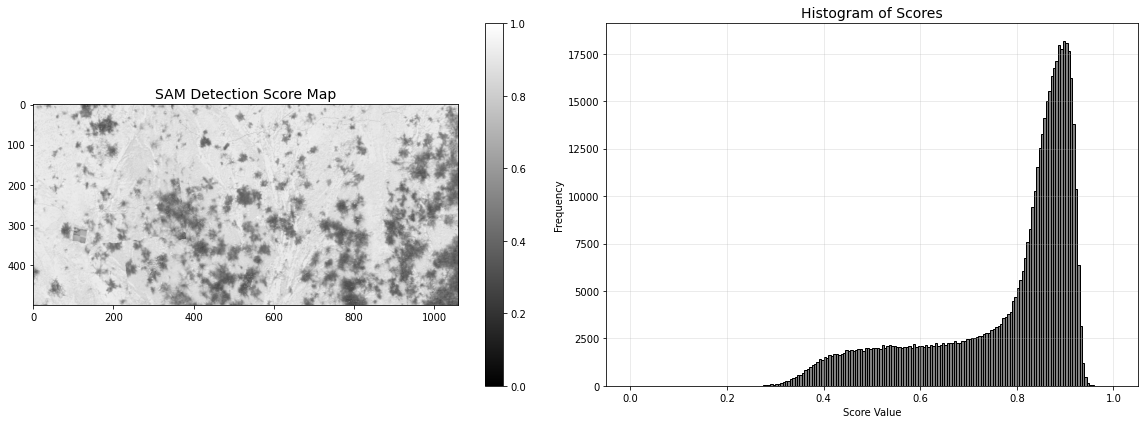

In [12]:
# Let's visulaize the SAM score map of the scene and its histogram
visualize_score_and_hist(sam_scores, title="SAM Detection Score Map")

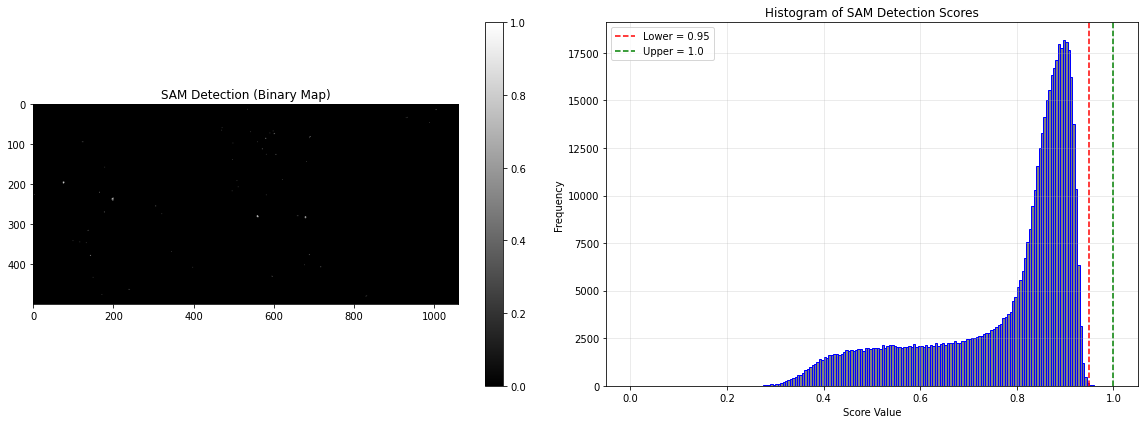

In [29]:
# Let's see how different threshold affect our binary map to locate targets
# I chose lower threshold = 0.95 and upper threshold = 1.0 for SAM.
# Play with various threshold values, and see how detection map changes.
visualize_detection_binary(sam_scores, lower_threshold=0.95, upper_threshold=1.0, title="SAM Detection")

Similarly, you can compute scores for other algorithms and visualize the results with various thresholds. Play with various thresholds in cells below to see how results change.


In [14]:
# Compute detection scores from other algorithms.
mf_scores = mf(hsi_data, target_spectrum)
ace_scores = ace(hsi_data, target_spectrum)
cem_scores = cem(hsi_data, target_spectrum)

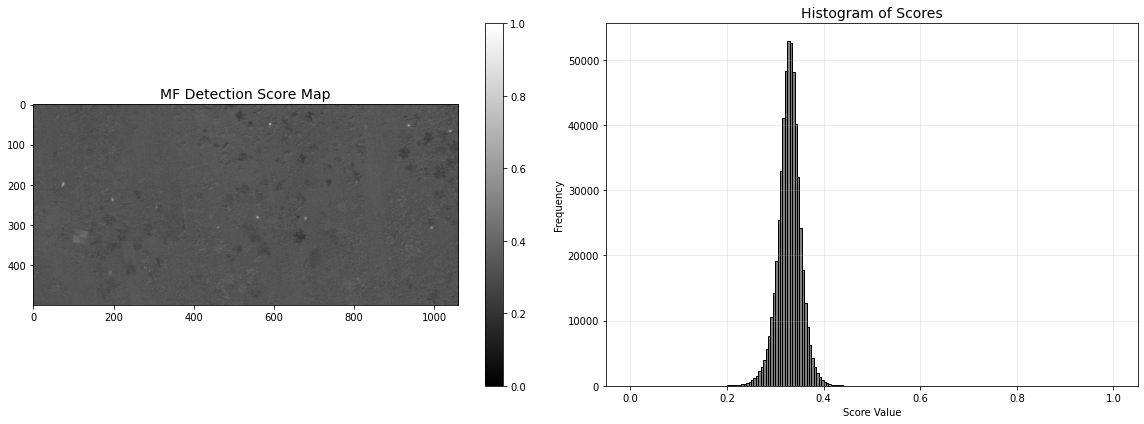

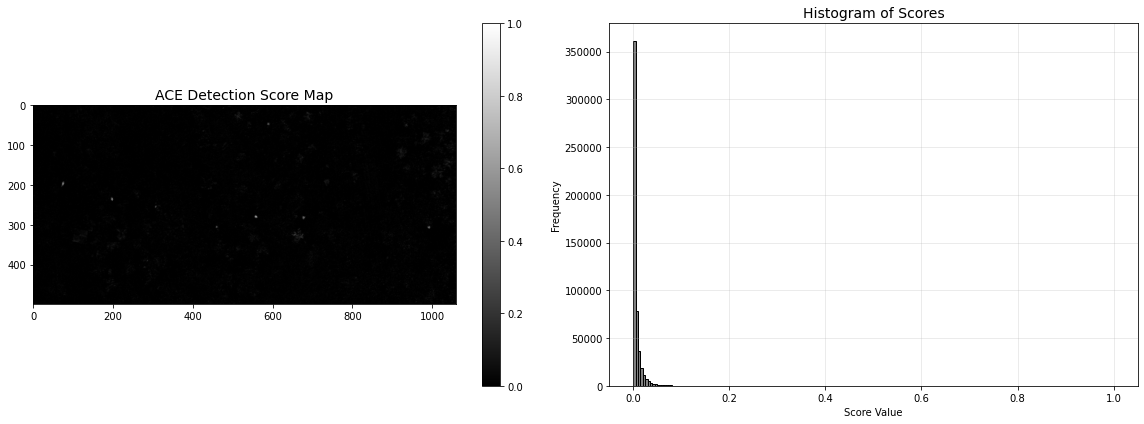

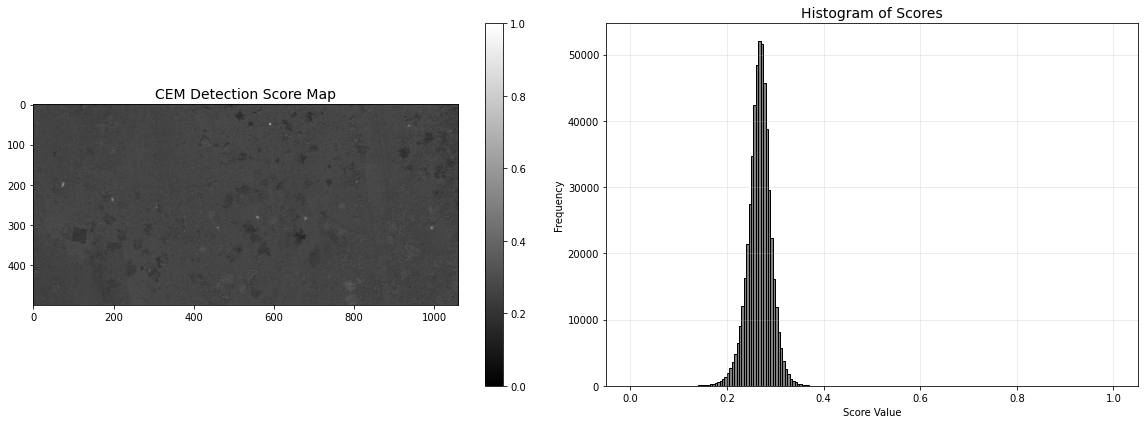

In [15]:
# Visualize detection scores from various algorithms.
visualize_score_and_hist(mf_scores, title="MF Detection Score Map")
visualize_score_and_hist(ace_scores, title="ACE Detection Score Map")
visualize_score_and_hist(cem_scores, title="CEM Detection Score Map")

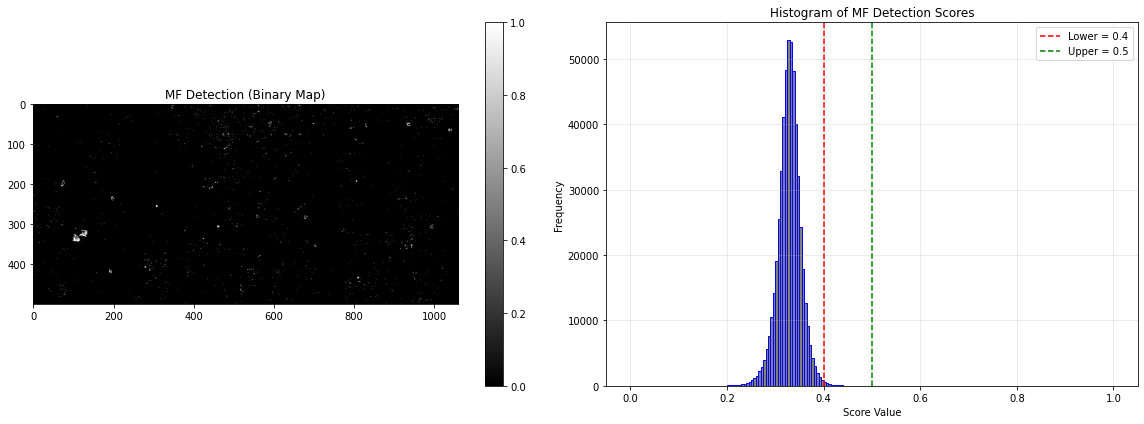

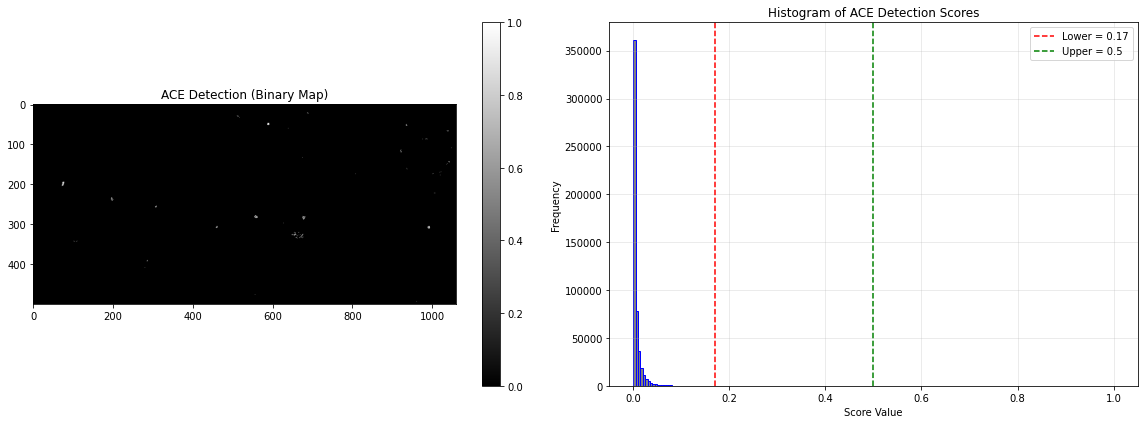

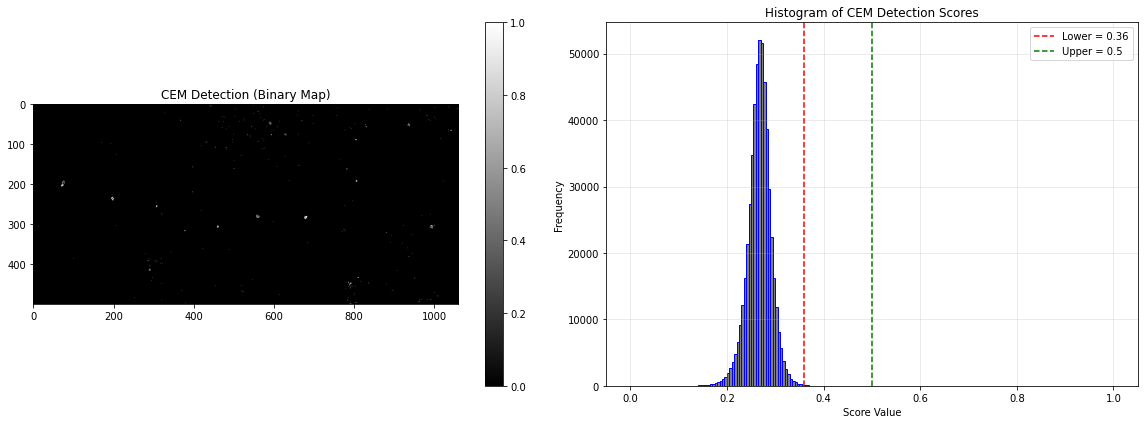

In [16]:
# Play with various thresholds
visualize_detection_binary(mf_scores, lower_threshold=0.4, upper_threshold=0.5, title="MF Detection")
visualize_detection_binary(ace_scores, lower_threshold=0.17, upper_threshold=0.5, title="ACE Detection")
visualize_detection_binary(cem_scores, lower_threshold=0.36, upper_threshold=0.5, title="CEM Detection")

# 3. Evaluation Metrics

After we computed detection scores from all algorithms, to compare their performances, we need to write another function to compute ROC curve, so, let's do that.

### 3.1. ROC curves

In [17]:
# Now, let's define other functions to compute ROC curve, Area under curve (AUC score) in both linear and log scale.

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def visualize_roc_linear_vs_log(detector_maps, detector_names, class_map_mask):
    """
    Plots ROC curves for multiple detectors side by side:
    - Left: linear scale
    - Right: log scale (FPR axis) with automatic lower bound
    """
    y_true = class_map_mask.flatten().astype(int)
    N_neg = np.sum(y_true == 0)

    plt.figure(figsize=(16, 6))

    # -------- LEFT PLOT: Linear Scale --------
    ax1 = plt.subplot(1, 2, 1)
    for scores, name in zip(detector_maps, detector_names):
        y_score = scores.flatten()
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    ax1.plot([0, 1], [0, 1], 'k--', label="Random")
    ax1.set_title("ROC Curves (Linear Scale)", fontsize=14)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="lower right")

    # Top axis for pixel counts
    ax1_top = ax1.twiny()
    ax1_top.set_xlim(ax1.get_xlim())
    fpr_ticks = np.linspace(0, 1, 6)
    fp_counts = (fpr_ticks * N_neg).astype(int)
    ax1_top.set_xticks(fpr_ticks)
    ax1_top.set_xticklabels(fp_counts)
    ax1_top.set_xlabel("False Positives (pixel count)", fontsize=12)

    # -------- RIGHT PLOT: Log Scale --------
    ax2 = plt.subplot(1, 2, 2)
    min_nonzero_fpr = np.inf

    # Find the smallest nonzero FPR across all detectors
    for scores in detector_maps:
        y_score = scores.flatten()
        fpr, tpr, _ = roc_curve(y_true, y_score)
        nonzero_fpr = fpr[fpr > 0]
        if len(nonzero_fpr) > 0:
            min_nonzero_fpr = min(min_nonzero_fpr, np.min(nonzero_fpr))

    # If no nonzero FPR found, default to 1e-6
    if min_nonzero_fpr == np.inf:
        min_nonzero_fpr = 1e-6

    # Plot each detector
    for scores, name in zip(detector_maps, detector_names):
        y_score = scores.flatten()
        fpr, tpr, _ = roc_curve(y_true, y_score)

        # Replace zeros with minimum nonzero FPR
        fpr_plot = np.where(fpr == 0, min_nonzero_fpr, fpr)
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr_plot, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    ax2.plot([min_nonzero_fpr, 1], [0, 1], 'k--', label="Random")
    ax2.set_xscale("log")
    ax2.set_title("ROC Curves (Log Scale)", fontsize=14)
    ax2.set_xlabel("False Positive Rate (log scale)")
    ax2.set_ylabel("True Positive Rate")
    ax2.grid(True, alpha=0.3, which="both")
    ax2.legend(loc="lower right")

    # Top axis for pixel counts
    ax2_top = ax2.twiny()
    ax2_top.set_xscale("log")
    ax2_top.set_xlim(ax2.get_xlim())
    fpr_ticks_log = np.logspace(np.log10(min_nonzero_fpr), 0, 6)
    fp_counts_log = (fpr_ticks_log * N_neg).astype(int)
    ax2_top.set_xticks(fpr_ticks_log)
    ax2_top.set_xticklabels(fp_counts_log)
    ax2_top.set_xlabel("False Positives (pixel count)", fontsize=12)

    plt.tight_layout()
    plt.show()


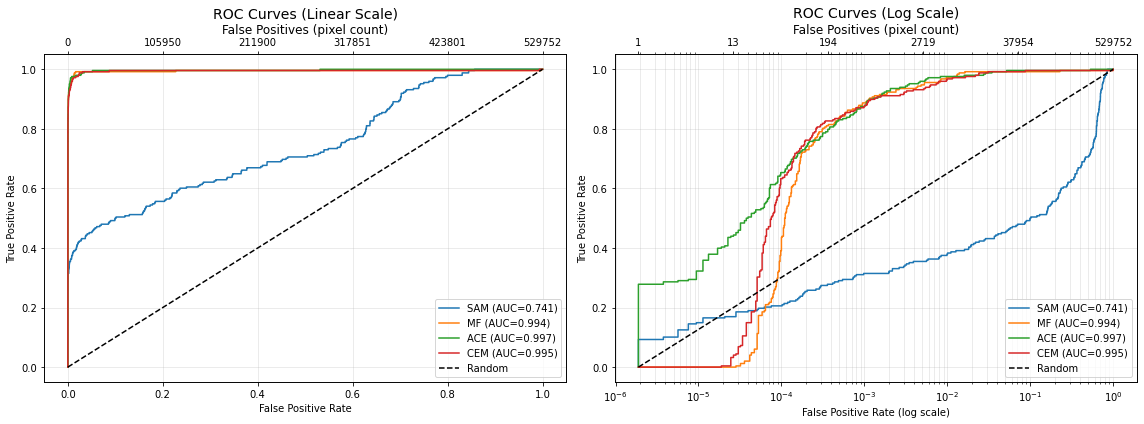

In [18]:
# Let's plot ROC curves for all the algorithms above.
detector_maps = [sam_scores, mf_scores, ace_scores, cem_scores]
detector_names = ["SAM", "MF", "ACE", "CEM"]
#Visualize the ROC curve, compute Area under curve (AUC) score to compare performances of various algorithms.
visualize_roc_linear_vs_log(detector_maps, detector_names, class_map_mask)

### 3.2 Plot Precision Recall Curves

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import os 

def plot_precision_recall_curve(detection_maps, names, ground_truth_mask, save_path=None):
    # Flatten ground truth
    y_true = ground_truth_mask.flatten()
    
    # Set up the plot
    plt.figure(figsize=(9, 6))
    
    # Store results
    results = {}
    
    # Define colors for different models
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    # Plot precision-recall curve for each model
    for i, (scores, name) in enumerate(zip(detection_maps, names)):
        # Flatten detection scores
        y_scores = scores.flatten()
        
        # Calculate precision-recall curve
        precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
        
        # Calculate average precision
        ap = average_precision_score(y_true, y_scores)
        
        # Store results
        results[name] = {
            'precision': precision,
            'recall': recall,
            'thresholds': thresholds,
            'average_precision': ap
        }
        
        # Plot the curve
        color = colors[i % len(colors)]
        plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})', 
                linewidth=2, color=color)
    
    # Add baseline (random classifier)
    baseline = np.sum(y_true) / len(y_true)
    # plt.plot([0, 1], [baseline, baseline], 'k--', label=f'Random', linewidth=1)
    
    # Formatting
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.xlabel('Recall', fontsize=20)
    plt.ylabel('Precision', fontsize=20)
    plt.title('Precision-Recall Curves for Test Region', fontsize=24)
    plt.legend(loc='best', fontsize=19)
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    
    # Save or show
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)  
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Precision-Recall curve saved to: {save_path}")
    
    plt.show()
    
    return results

Precision-Recall curve saved to: images/pr_curve_pfm1.pdf


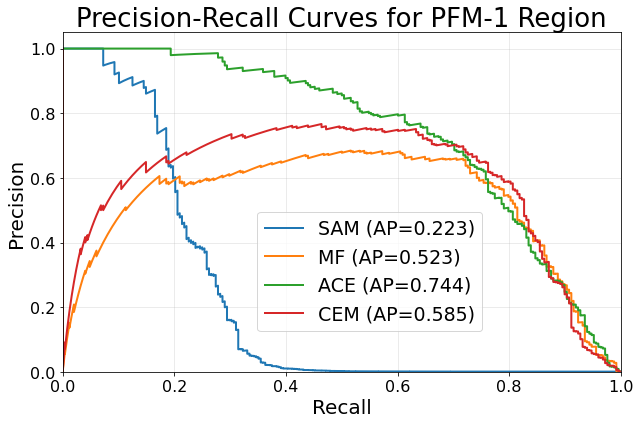

In [20]:
pr_results = plot_precision_recall_curve(
    detection_maps=[sam_scores, mf_scores, ace_scores, cem_scores],
    names=["SAM", "MF", "ACE", "CEM"],
    ground_truth_mask=class_map_mask,
    save_path='images/pr_curve_pfm1.pdf'  # Remove this line to just display
)